In [ ]:
import os, numpy as np, warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("GPU:", tf.config.list_physical_devices('GPU'))

DATA_DIR = '/kaggle/input/datasets/mostafaabla/garbage-classification/garbage_classification'
IMG_SIZE = 160
BATCH    = 32
N_CLASSES = 12

CLASS_NAMES = sorted(os.listdir(DATA_DIR))
print(f"Classes: {CLASS_NAMES}")

2026-03-18 05:11:36.646571: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773810696.833637      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773810696.885052      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773810697.355469      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773810697.355506      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773810697.355510      55 computation_placer.cc:177] computation placer alr

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


In [ ]:
# ── Load data using tf.data (CORRECT way) ──
def load_dataset(subset):
    ds = tf.keras.utils.image_dataset_from_directory(
        DATA_DIR,
        validation_split=0.2,
        subset=subset,
        seed=42,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH,
        label_mode='categorical'
    )
    return ds

train_ds = load_dataset('training')
val_ds   = load_dataset('validation')

# Prefetch for speed
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)

print("Datasets loaded ✅")

Found 15515 files belonging to 12 classes.
Using 12412 files for training.


I0000 00:00:1773810742.680095      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 15515 files belonging to 12 classes.
Using 3103 files for validation.
Datasets loaded ✅


In [ ]:
# ── Preprocessing inside model ──
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Rescale + augment inside model
x = tf.keras.layers.Rescaling(1./255)(inputs)
x = tf.keras.layers.RandomFlip('horizontal')(x)
x = tf.keras.layers.RandomRotation(0.1)(x)

# MobileNetV2 with correct [-1,1] scaling
x = tf.keras.layers.Rescaling(2.0, offset=-1.0)(x)  # [0,1] -> [-1,1]

base = MobileNetV2(weights='imagenet', include_top=False,
                   input_tensor=None,
                   input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False

x = base(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(N_CLASSES, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)
print(f"Model ready | Params: {model.count_params():,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model ready | Params: 2,621,388


In [ ]:
# ── PHASE 1 ──
print("\nPHASE 1 — Head only")
model.compile(optimizer=Adam(1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

h1 = model.fit(
    train_ds, epochs=8,
    validation_data=val_ds,
    callbacks=[
        ModelCheckpoint('/kaggle/working/best.keras',
                        save_best_only=True,
                        monitor='val_accuracy'),
        EarlyStopping(patience=3, restore_best_weights=True)
    ], verbose=1
)
print(f"Phase 1 best: {max(h1.history['val_accuracy'])*100:.1f}%")


PHASE 1 — Head only
Epoch 1/8


I0000 00:00:1773810757.437233     143 cuda_dnn.cc:529] Loaded cuDNN version 91002


388/388 ━━━━━━━━━━━━━━━━━━━━ 44s 90ms/step - accuracy: 0.6978 - loss: 0.9930 - val_accuracy: 0.9275 - val_loss: 0.2376
Epoch 2/8
388/388 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.8761 - loss: 0.3806 - val_accuracy: 0.9310 - val_loss: 0.2158
Epoch 3/8
388/388 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.8939 - loss: 0.3370 - val_accuracy: 0.9336 - val_loss: 0.2048
Epoch 4/8
388/388 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9060 - loss: 0.2873 - val_accuracy: 0.9362 - val_loss: 0.1952
Epoch 5/8
388/388 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.9103 - loss: 0.2719 - val_accuracy: 0.9439 - val_loss: 0.1867
Epoch 6/8
388/388 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9120 - loss: 0.2519 - val_accuracy: 0.9417 - val_loss: 0.1889
Epoch 7/8
388/388 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.9199 - loss: 0.2529 - val_accuracy: 0.9433 - val_loss: 0.1813
Epoch 8/8
388/388 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9213 - loss: 0.2291 - val_accuracy: 0.94

In [ ]:
# ── PHASE 2 ──
print("\nPHASE 2 — Fine-tune")
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

h2 = model.fit(
    train_ds, epochs=5,
    validation_data=val_ds,
    callbacks=[
        ModelCheckpoint('/kaggle/working/best.keras',
                        save_best_only=True,
                        monitor='val_accuracy'),
        EarlyStopping(patience=3, restore_best_weights=True)
    ], verbose=1
)
print(f"Phase 2 best: {max(h2.history['val_accuracy'])*100:.1f}%")


PHASE 2 — Fine-tune
Epoch 1/5
388/388 ━━━━━━━━━━━━━━━━━━━━ 28s 49ms/step - accuracy: 0.8546 - loss: 0.4591 - val_accuracy: 0.9471 - val_loss: 0.1781
Epoch 2/5
388/388 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.8910 - loss: 0.3399 - val_accuracy: 0.9459 - val_loss: 0.1745
Epoch 3/5
388/388 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.9027 - loss: 0.3071 - val_accuracy: 0.9459 - val_loss: 0.1709
Epoch 4/5
388/388 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.9094 - loss: 0.2830 - val_accuracy: 0.9465 - val_loss: 0.1700
Epoch 5/5
388/388 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.9140 - loss: 0.2590 - val_accuracy: 0.9468 - val_loss: 0.1647
Phase 2 best: 94.7%


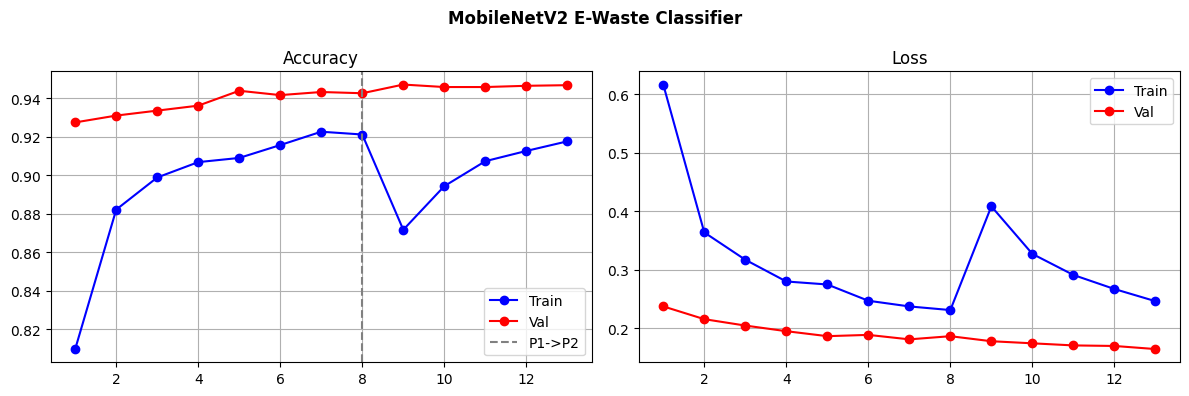

In [ ]:
# ── Plots ──
acc      = h1.history['accuracy']     + h2.history['accuracy']
val_acc  = h1.history['val_accuracy'] + h2.history['val_accuracy']
loss     = h1.history['loss']         + h2.history['loss']
val_loss = h1.history['val_loss']     + h2.history['val_loss']
ep = range(1, len(acc)+1)

fig, ax = plt.subplots(1,2,figsize=(12,4))
ax[0].plot(ep,acc,'b-o',label='Train')
ax[0].plot(ep,val_acc,'r-o',label='Val')
ax[0].axvline(x=len(h1.history['accuracy']),
              color='gray',linestyle='--',label='P1->P2')
ax[0].set_title('Accuracy'); ax[0].legend(); ax[0].grid(True)
ax[1].plot(ep,loss,'b-o',label='Train')
ax[1].plot(ep,val_loss,'r-o',label='Val')
ax[1].set_title('Loss'); ax[1].legend(); ax[1].grid(True)
plt.suptitle('MobileNetV2 E-Waste Classifier',fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/curves.png',dpi=120)
plt.show()

In [ ]:
# ── Eval ──
best = tf.keras.models.load_model('/kaggle/working/best.keras')
y_pred_list, y_true_list = [], []
for imgs, labels in val_ds:
    preds = best.predict(imgs, verbose=0)
    y_pred_list.extend(np.argmax(preds, axis=1))
    y_true_list.extend(np.argmax(labels.numpy(), axis=1))

y_pred = np.array(y_pred_list)
y_true = np.array(y_true_list)

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

     battery       0.96      0.94      0.95       180
  biological       0.98      0.94      0.96       195
 brown-glass       0.94      0.93      0.94       111
   cardboard       0.95      0.91      0.93       176
     clothes       0.99      0.99      0.99      1065
 green-glass       0.93      0.96      0.94       122
       metal       0.84      0.86      0.85       145
       paper       0.87      0.94      0.90       218
     plastic       0.91      0.81      0.86       189
       shoes       0.95      0.98      0.96       407
       trash       0.93      0.96      0.94       143
 white-glass       0.85      0.89      0.87       152

    accuracy                           0.95      3103
   macro avg       0.93      0.93      0.93      3103
weighted avg       0.95      0.95      0.95      3103



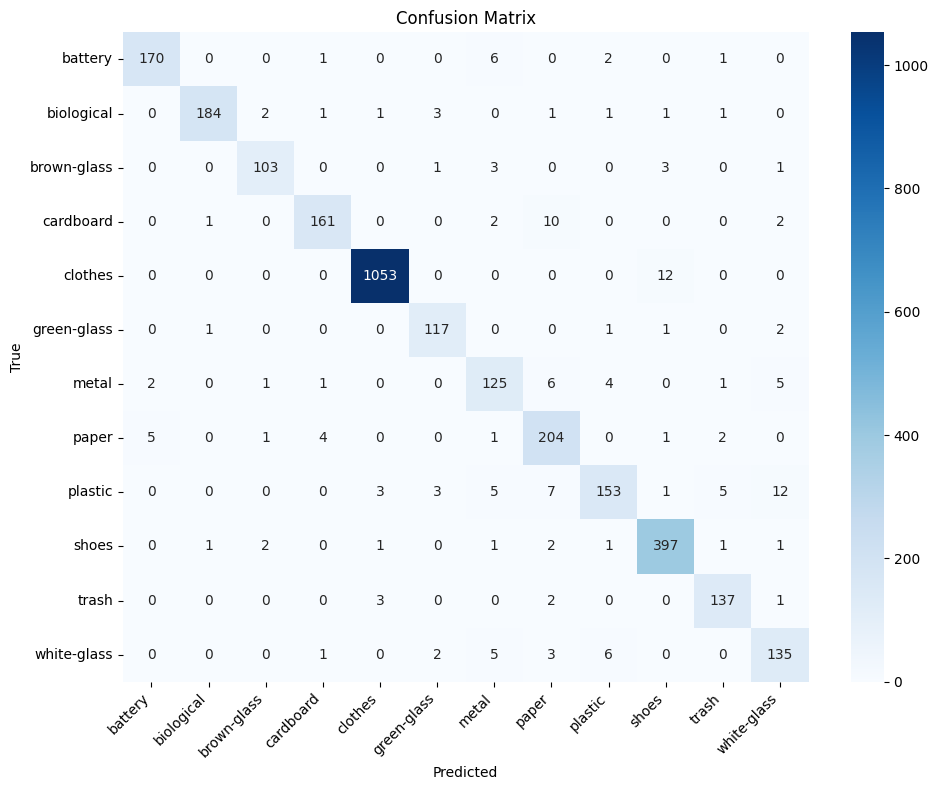


FINAL ACCURACY: 94.71%
Model saved: /kaggle/working/best.keras


In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/kaggle/working/cm.png',dpi=120)
plt.show()

final_acc = np.sum(y_pred==y_true)/len(y_true)
print(f"\nFINAL ACCURACY: {final_acc*100:.2f}%")
print("Model saved: /kaggle/working/best.keras")